In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

x,y_true = make_moons(n_samples=500, noise=0.05, random_state=0)
data=pd.DataFrame(x,columns=["Feature 1","Feature 2"])
print(data.head(10))

   Feature 1  Feature 2
0   0.391849   0.904123
1  -0.095541   0.458993
2   0.111626   0.099991
3   1.761204  -0.124941
4   1.907206  -0.099912
5   1.079941   0.207630
6   0.294507  -0.259306
7   2.016738   0.368361
8  -0.523199   1.009976
9  -0.357408   0.987053


In [4]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(data)
print(x_scaled[:5])

[[-0.12479331  1.33200359]
 [-0.68794229  0.42971273]
 [-0.44857439 -0.29799392]
 [ 1.45741102 -0.75393599]
 [ 1.62610638 -0.7032023 ]]


In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
cluster_labels=kmeans.fit_predict(x_scaled)
data['Cluster_labels']=cluster_labels
print(data.head(10))

   Feature 1  Feature 2  Cluster_labels
0   0.391849   0.904123               0
1  -0.095541   0.458993               0
2   0.111626   0.099991               0
3   1.761204  -0.124941               1
4   1.907206  -0.099912               1
5   1.079941   0.207630               1
6   0.294507  -0.259306               1
7   2.016738   0.368361               1
8  -0.523199   1.009976               0
9  -0.357408   0.987053               0


   Feature 1  Feature 2  Cluster_labels  dbscan_cluster
0   0.391849   0.904123               0               0
1  -0.095541   0.458993               0               1
2   0.111626   0.099991               0               1
3   1.761204  -0.124941               1               1
4   1.907206  -0.099912               1               1
5   1.079941   0.207630               1               0
6   0.294507  -0.259306               1               1
7   2.016738   0.368361               1               1
8  -0.523199   1.009976               0               0
9  -0.357408   0.987053               0               0


<Axes: xlabel='Feature 1', ylabel='Feature 2'>

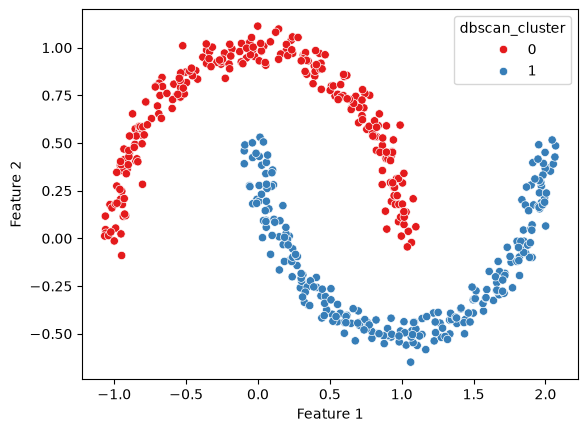

In [9]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
cluster_labels_dbscan = dbscan.fit_predict(x_scaled)
data['dbscan_cluster'] = cluster_labels_dbscan
print(data.head(10))

sns.scatterplot(x='Feature 1', y='Feature 2', hue='dbscan_cluster', data=data,palette='Set1')

Text(0.5, 1.0, 'DBSCAN Clustering')

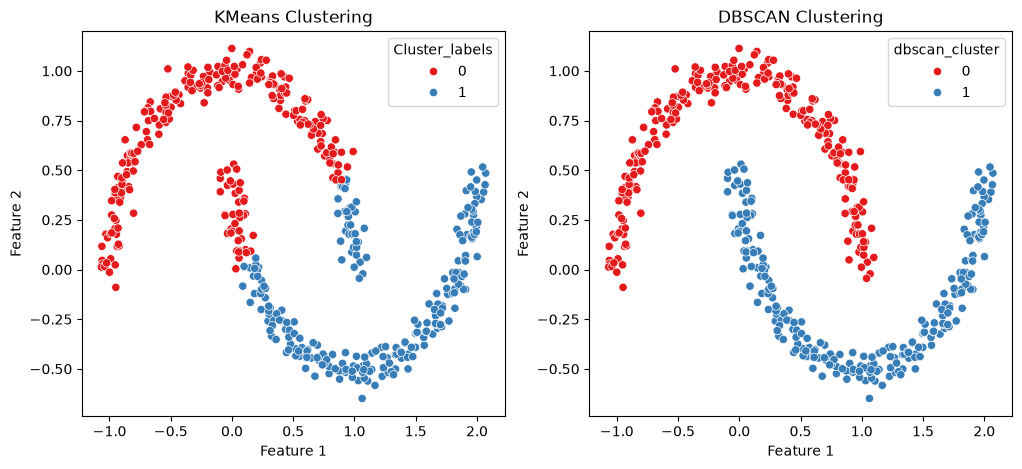

In [ ]:
# Comparing KMeans and DBSCAN clustering results visually
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Feature 1', y='Feature 2', hue='Cluster_labels', data=data, palette='Set1')
plt.title('KMeans Clustering')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Feature 1', y='Feature 2', hue='dbscan_cluster', data=data, palette='Set1')
plt.title('DBSCAN Clustering')

# DBSCAN handles noise points by assigning them a cluster label of -1,
# which can be seen in the DBSCAN clustering plot.
# KMeans, on the other hand, assigns every point to a cluster,
# which may not be ideal for datasets with noise or irregular shapes.


,eps,n_clusters,n_noise
0,0.1,16,61
1,0.2,2,0
2,0.3,2,0
3,0.4,2,0
4,0.5,2,0


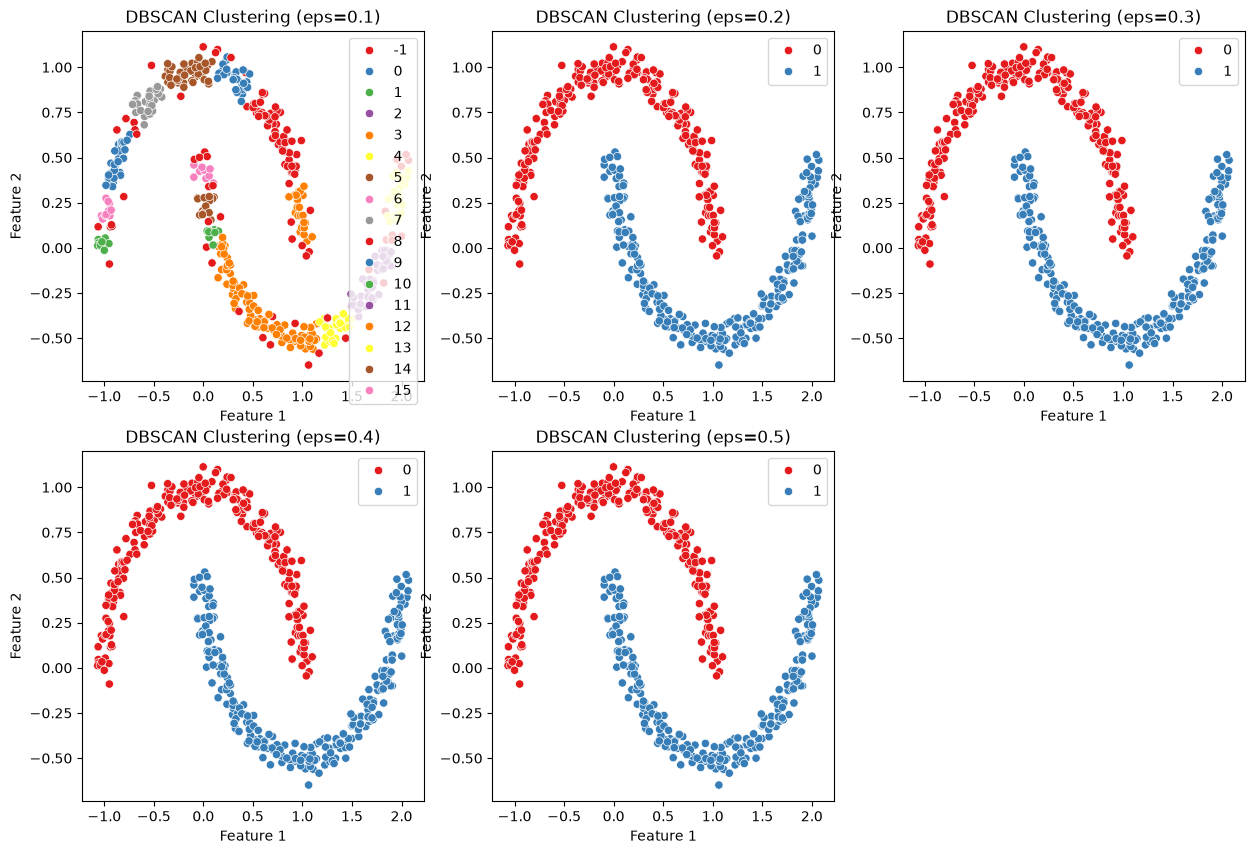

In [ ]:
# Experiment with different values of eps in DBSCAN to see how it affects the clustering results.
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
plt.figure(figsize=(15, 10))
for i, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_Labels_dbscan = dbscan.fit_predict(x_scaled)
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x='Feature 1', y='Feature 2', hue=cluster_Labels_dbscan, data=data, palette='Set1')
    plt.title(f'DBSCAN Clustering (eps={eps})')

# Creating a table to show eps, number of clusters, and number of noise points
results = []
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_Labels_dbscan = dbscan.fit_predict(x_scaled)
    n_clusters = len(set(cluster_Labels_dbscan)) - (1 if -1 in cluster_Labels_dbscan else 0)
    n_noise = list(cluster_Labels_dbscan).count(-1)
    results.append({'eps': eps, 'n_clusters' : n_clusters, 'n_noise': n_noise})
results_df = pd.DataFrame(results)
results_df

# For moon dataset the optimal eps value is around 0.3, 
# which results in 2 clusters and a small number of noise points.

In [24]:
# Creating High-Dimensional Dataset
from sklearn.datasets import make_blobs
x, y_true = make_blobs(n_samples=500, n_features=6, centers=4, cluster_std=1.0, random_state=42)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pd.DataFrame(x_scaled)

,0,1,2,3,4,5
0,-1.152542,0.770706,0.349367,1.069421,-1.638021,1.470515
1,0.104384,-0.991268,0.704397,-0.936032,0.601599,-0.529060
2,-0.156750,1.121362,0.852715,0.719261,-0.212725,-1.417344
3,-1.180125,0.910768,0.101385,1.150839,-1.460057,1.331802
4,-1.482800,0.782397,0.495451,1.086987,-0.745312,1.455738
...,...,...,...,...,...,...
495,1.716171,-0.890260,-1.760294,-0.941710,0.189231,-0.064907
496,-1.571765,0.738738,0.319218,1.512649,-1.672348,1.557573
497,0.090871,-0.816135,0.486504,-1.374672,1.097144,-0.350691
498,-0.111099,0.959180,0.817666,0.522422,-0.365738,-0.981974


In [33]:
# Applying PCA on the scaled high-dimensional data.
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(x_pca, columns=['PCA1', 'PCA2'])
pca_df['True_Cluster'] = y_true
pca_df = pd.DataFrame(pca_df.head(10))
print(pca_df)

# Display the explained variance ratio of the two components.
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
print(f"PCA1: {explained_variance_ratio[0]:.4f}, PCA2: {explained_variance_ratio[1]:.4f}")

       PCA1      PCA2  True_Cluster
0  2.509524  1.280952             1
1 -1.052644 -0.773798             3
2  1.064574 -1.713426             0
3  2.429547  1.235971             1
4  2.317693  0.994984             1
5 -2.377354  0.526424             2
6  0.982651 -1.567311             0
7  1.555463 -1.351870             0
8 -1.394092 -0.918685             3
9 -2.096370  0.558925             2

Explained Variance Ratio:
PCA1: 0.6762, PCA2: 0.2139


<Axes: title={'center': 'PCA of High-Dimensional Data'}, xlabel='PCA1', ylabel='PCA2'>

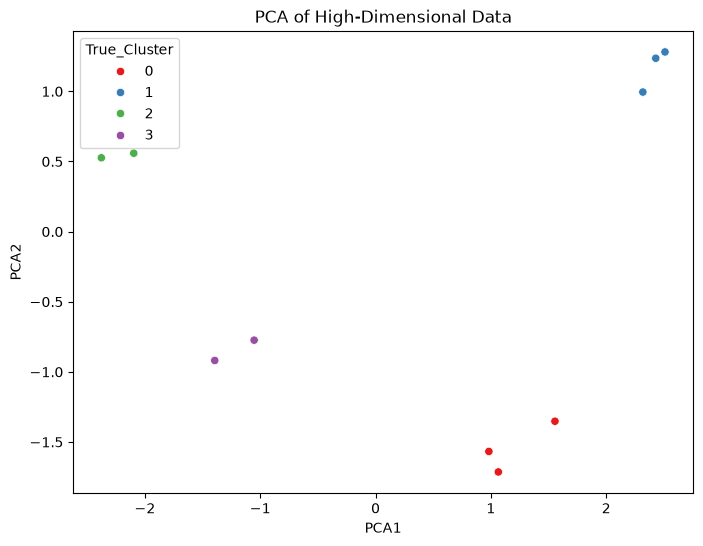

In [38]:
# Visualizing PCA Results
plt.figure(figsize=(8, 6))
plt.title('PCA of High-Dimensional Data')
sns.scatterplot(x='PCA1', y='PCA2', hue='True_Cluster', data=pca_df, palette='Set1')

# Explained Variance tells about information retained in the PCA tranformation.
# It indicates how much of the original data's variance is captured by each principal component.

<Axes: title={'center': 'DBSCAN Clustering on IRIS Dataset'}, xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

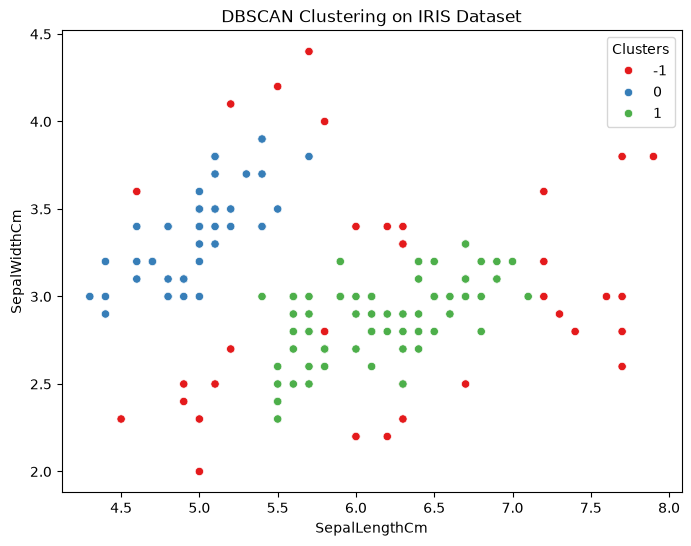

In [48]:
iris = pd.read_csv('Iris.csv')
df = pd.DataFrame(iris, columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])
num_features = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(num_features)

dbscan_iris = DBSCAN(eps=0.5, min_samples=5)
df['Clusters'] = dbscan_iris.fit_predict(iris_scaled)

# Visualize in 2D
plt.figure(figsize=(8, 6))
plt.title('DBSCAN Clustering on IRIS Dataset')
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Clusters', data=df, palette='Set1')

<Axes: title={'center': 'PCA of Iris Dataset'}>

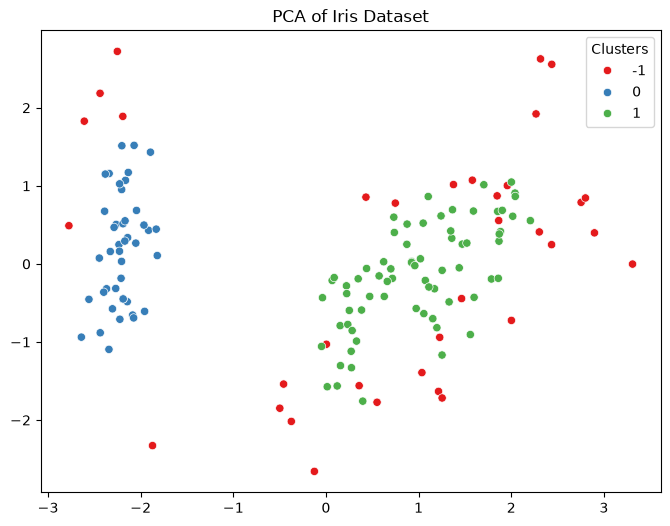

In [44]:
# Applying PCA to reduce to 2 components for visualization
pca_iris = PCA(n_components=2)
iris_pca = pca_iris.fit_transform(iris_scaled)

plt.figure(figsize=(8, 6))
plt.title('PCA of Iris Dataset')
sns.scatterplot(x=iris_pca[:, 0], y=iris_pca[:, 1], hue=df['Clusters'], palette='Set1')